# Homework 03

Your task is to train a neural network model that will improve upon your model from Homework 02
- Neural networks must be used (recurrent, convolutional or transformers)
- You can engineer features

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn torch einops

In [2]:
import numpy as np
import pandas as pd

import os
import time
import pickle

from sklearn.preprocessing import StandardScaler

from torch.utils.data import Dataset, DataLoader
from torch import optim
import torch.nn as nn
import torch

import IPython.display as dp
import matplotlib.pyplot as plt
import seaborn as sns

dp.set_matplotlib_formats("retina")
sns.set(style="whitegrid", font_scale=1.5)
sns.despine()

%matplotlib inline

<ipython-input-2-3b4cd18dc9a0>:19: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  dp.set_matplotlib_formats("retina")


<Figure size 640x480 with 0 Axes>

## Load data

In [3]:
with open("returns_NASDAQ_hist_daily_06102021-091329.pkl", "rb") as f:
    data = pickle.load(f)

In [4]:
data["Ticker"].unique()

array(['ATVI', 'ADBE', 'AMD', 'ALXN', 'ALGN', 'GOOG', 'AMZN', 'AAL',
       'AMGN', 'ADI', 'AAPL', 'AMAT', 'ASML', 'ADSK', 'ADP', 'BIDU',
       'BIIB', 'BMRN', 'BKNG', 'AVGO', 'CDNS', 'CELG', 'CERN', 'CHTR',
       'CHKP', 'CTAS', 'CSCO', 'CTXS', 'CTSH', 'CMCSA', 'COST', 'CSX',
       'CTRP', 'DLTR', 'EBAY', 'EA', 'EXPE', 'FB', 'FAST', 'FISV', 'FOX',
       'GILD', 'HAS', 'HSIC', 'IDXX', 'ILMN', 'INCY', 'INTC', 'INTU',
       'ISRG', 'JBHT', 'JD', 'KLAC', 'LRCX', 'LBTYA', 'LULU', 'MAR',
       'MXIM', 'MELI', 'MCHP', 'MU', 'MSFT', 'MDLZ', 'MNST', 'NTAP',
       'NTES', 'NFLX', 'NVDA', 'NXPI', 'ORLY', 'PCAR', 'PAYX', 'PYPL',
       'PEP', 'QCOM', 'REGN', 'ROST', 'SIRI', 'SWKS', 'SBUX', 'SYMC',
       'SNPS', 'TTWO', 'TSLA', 'TXN', 'KHC', 'TMUS', 'ULTA', 'UAL',
       'VRSN', 'VRSK', 'VRTX', 'WBA', 'WDC', 'WLTW', 'WDAY', 'WYNN',
       'XEL', 'XLNX'], dtype=object)

In [5]:
MY_TICKER = # YOUR CHOICE

In [6]:
data_ticker = data[data["Ticker"] == MY_TICKER].dropna()

In [7]:
data_ticker = data_ticker.sort_index().reset_index()

In [8]:
data_ticker.head()

,Time,Ticker,Close
0,2010-06-30,TSLA,-0.251151
1,2010-07-01,TSLA,-7.847251
2,2010-07-02,TSLA,-12.568306
3,2010-07-06,TSLA,-16.093750
4,2010-07-07,TSLA,-1.924271


<Axes: xlabel='Time'>

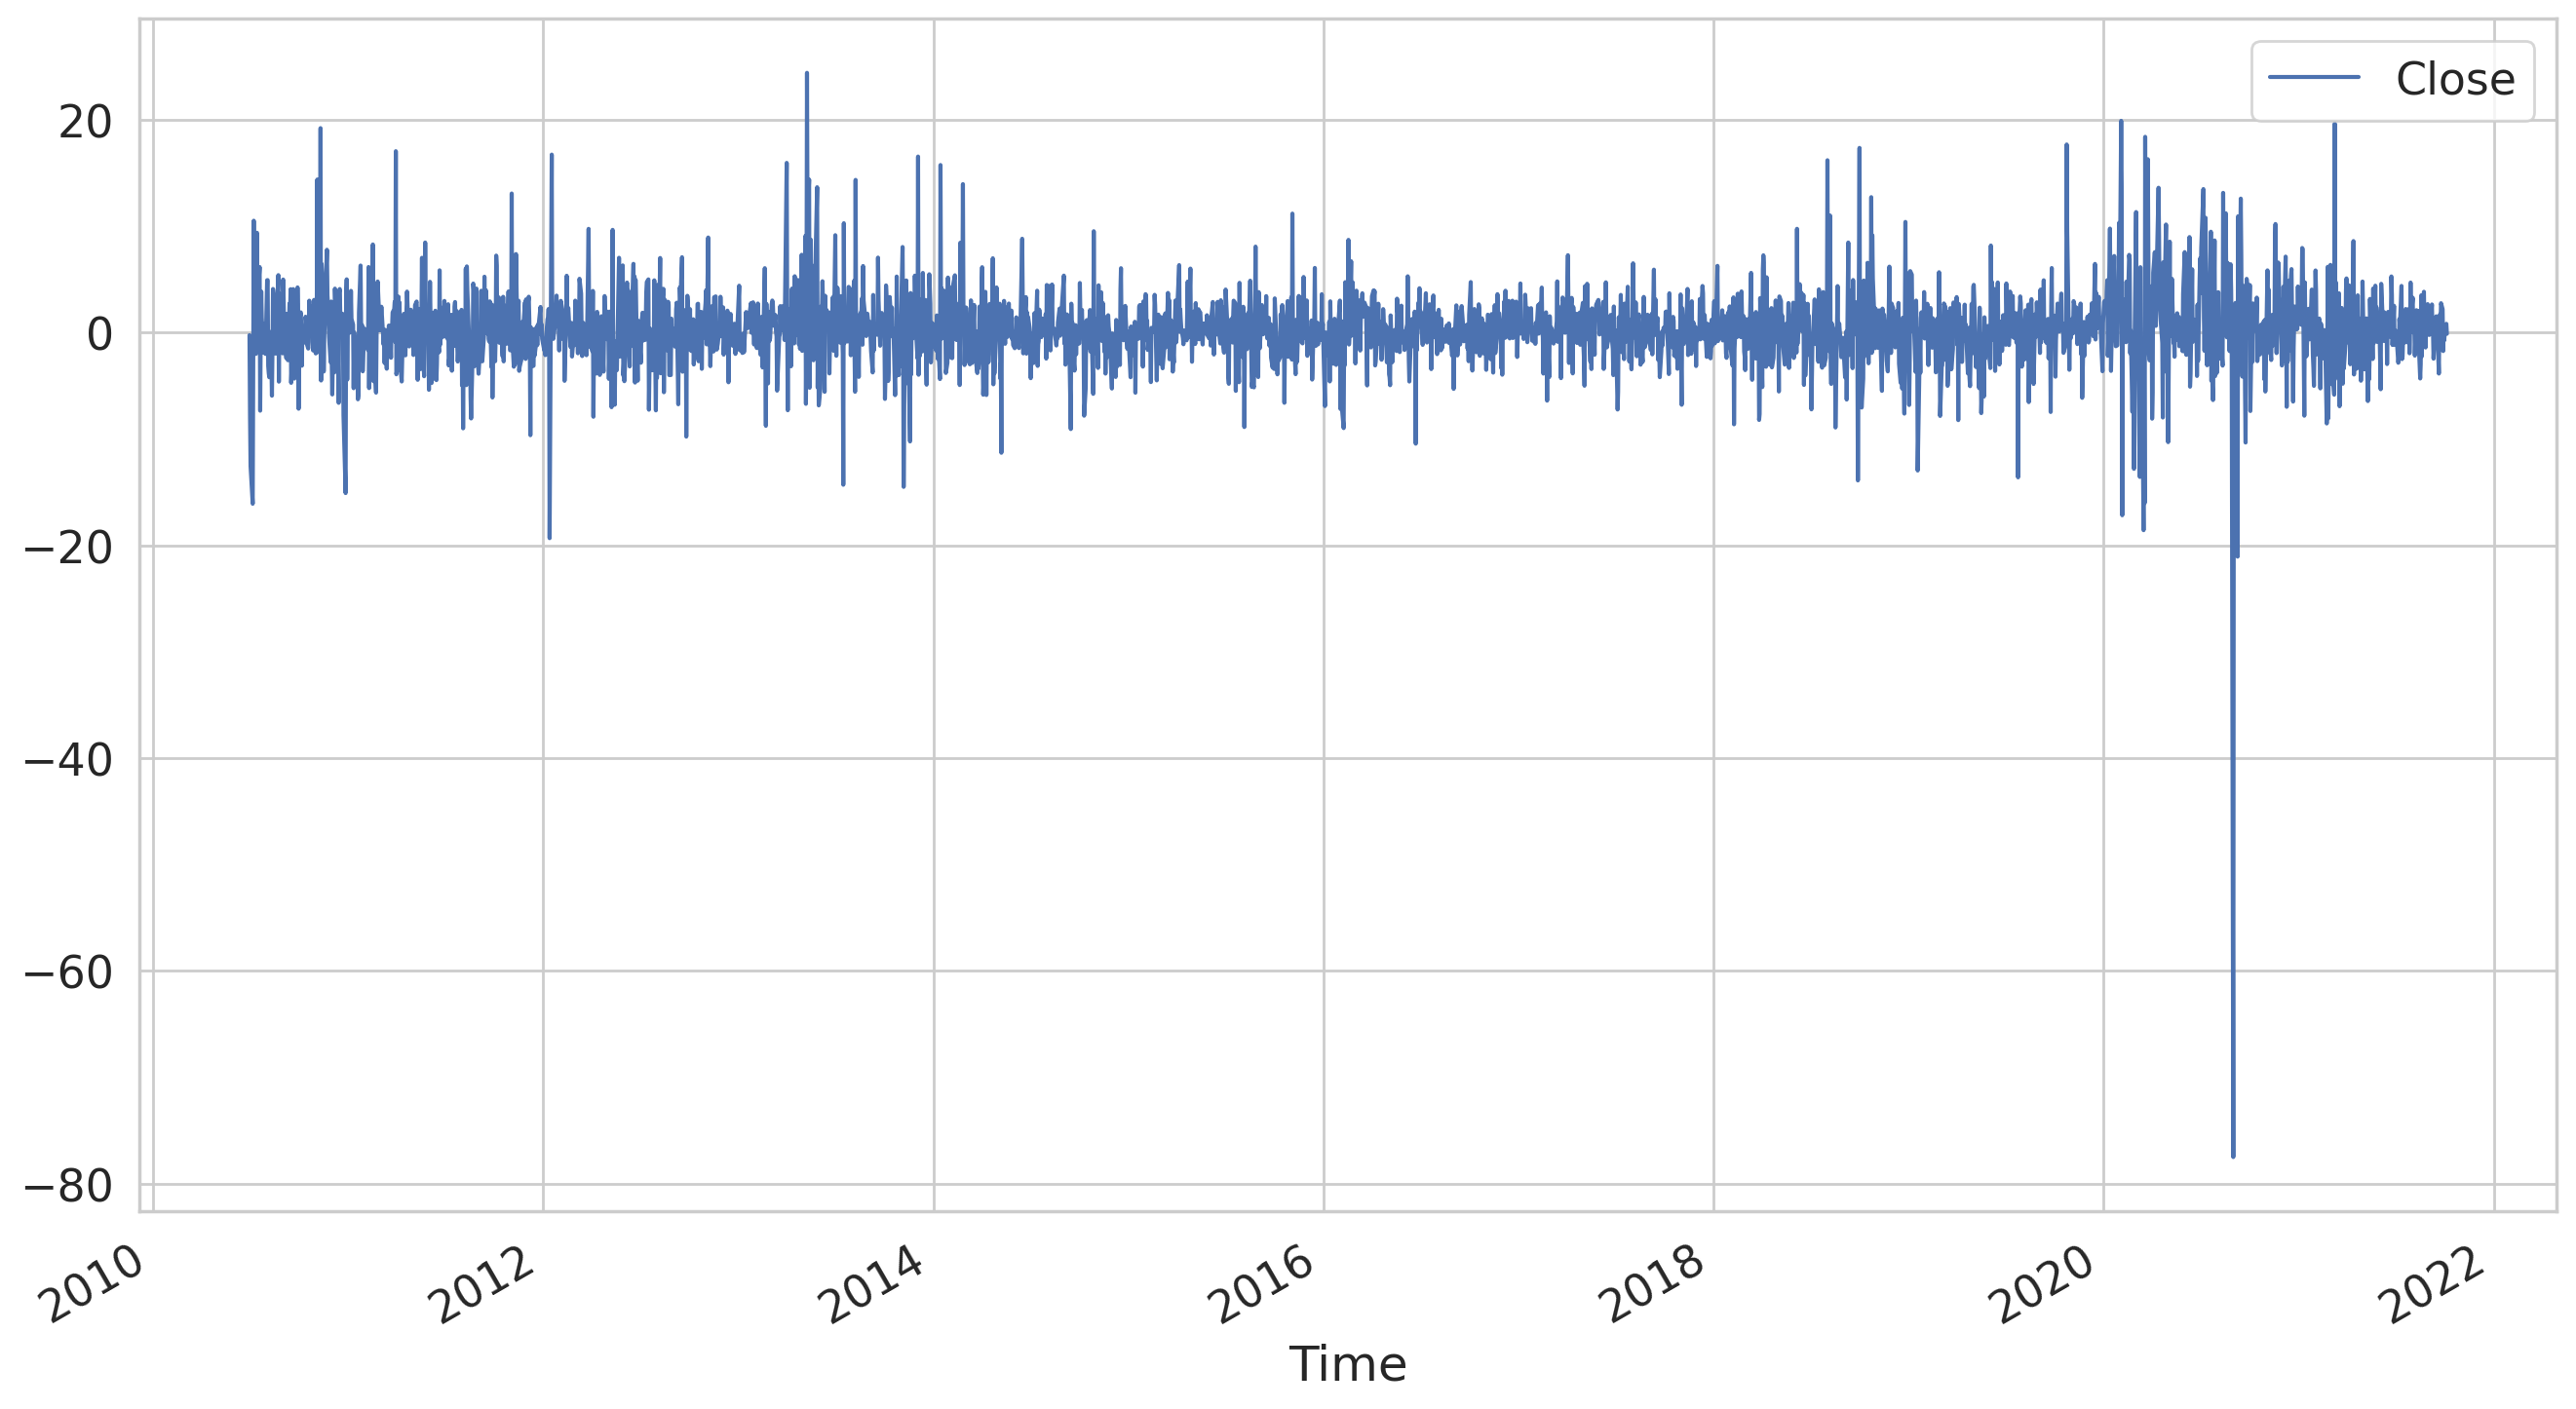

In [10]:
fig, ax = plt.subplots(figsize=(16,9))
data_ticker.plot(x="Time", y="Close", ax=ax)

## Dataset

Even though written for transformers, this dataset class can be used for time series forecasting with any sequence-processing neural network. For example, for a recurrent neural network, you may want to set `label_len = 0` and ignore the last two outputs (date encodings) from `__getitem__`.

In [54]:
class ReturnsDataset(Dataset):
    def __init__(
        self, data, flag='train', size=None,
        feature_cols=None, target_col='Close', scale=True, time_is_encoded=False
    ):
        self.seq_len = size[0]
        self.label_len = size[1]
        self.pred_len = size[2]

        assert flag in ['train', 'test']
        type_map = {'train': 0, 'test': 1}
        self.set_type = type_map[flag]

        self.feature_cols = feature_cols
        self.target_col = target_col
        self.scale = scale
        self.time_is_encoded = time_is_encoded

        self.data_raw = data
        self.__read_data__()

    def __read_data__(self):
        self.scaler = StandardScaler()

        train_end = data_ticker.index[data_ticker["Time"] == "2018-12-31"][0]

        border1s = [0, train_end - self.seq_len]
        border2s = [train_end, -1]
        border1 = border1s[self.set_type]
        border2 = border2s[self.set_type]

        if self.feature_cols is not None:
            df_data = self.data_raw[self.feature_cols + [self.target_col]]
        else:
            df_data = self.data_raw[[self.target_col]]

        if self.scale:
            train_data = df_data[border1s[0]:border2s[0]]
            self.scaler.fit(train_data.values)
            data = self.scaler.transform(df_data.values)
        else:
            data = df_data.values

        df_stamp = self.data_raw[['Time']][border1:border2]
        df_stamp['Time'] = pd.to_datetime(df_stamp['Time'])
        if not self.time_is_encoded:
            df_stamp['month'] = df_stamp['Time'].dt.month
            df_stamp['day'] = df_stamp['Time'].dt.day
            df_stamp['weekday'] = df_stamp['Time'].dt.weekday
            data_stamp = df_stamp.drop('Time', axis=1).values

        self.data_x = data[border1:border2]
        self.data_y = data[border1:border2]
        self.data_stamp = data_stamp

    def __getitem__(self, index):
        s_begin = index
        s_end = s_begin + self.seq_len
        r_begin = s_end - self.label_len
        r_end = s_end + self.pred_len

        seq_x = self.data_x[s_begin:s_end]
        seq_y = self.data_y[r_begin:r_end]
        seq_x_mark = self.data_stamp[s_begin:s_end]
        seq_y_mark = self.data_stamp[r_begin:r_end]

        return seq_x, seq_y, seq_x_mark, seq_y_mark

    def __len__(self):
        return len(self.data_x) - self.seq_len - self.pred_len + 1

    def inverse_transform(self, data):
        return self.scaler.inverse_transform(data)

In [68]:
def data_provider(data, flag, seq_len, label_len, pred_len, feature_cols, target_col, scale, batch_size, num_workers):
    ds = ReturnsDataset(
        data,
        flag=flag,
        size=[seq_len, label_len, pred_len],
        feature_cols=feature_cols,
        target_col=target_col,
        scale=scale,
        time_is_encoded=False
    )
    dl = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=flag != 'test',
        num_workers=num_workers,
        drop_last=True
    )
    return ds, dl

## Transformer models special section

If you are not using transformer models, this section can be ignored or removed.

In [56]:
!git clone https://github.com/MAZiqing/FEDformer.git

Cloning into 'FEDformer'...
remote: Enumerating objects: 194, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 194 (delta 60), reused 43 (delta 43), pack-reused 112 (from 1)
Receiving objects: 100% (194/194), 74.40 KiB | 2.98 MiB/s, done.
Resolving deltas: 100% (109/109), done.


In [57]:
cd FEDformer

/content/FEDformer/FEDformer/FEDformer


In [58]:
from models import FEDformer, Autoformer, Informer, Transformer
from utils.tools import EarlyStopping, adjust_learning_rate, visual
from utils.metrics import metric

In [59]:
class Experiment():
    def __init__(self, data, args):
        self.data = data
        self.args = args
        self.device = torch.device('cuda:{}'.format(0))
        self.model = self._build_model().to(self.device)

    def _build_model(self):
        model_dict = {
            'FEDformer': FEDformer,
            'Autoformer': Autoformer,
            'Transformer': Transformer,
            'Informer': Informer
        }
        model = model_dict[self.args.model].Model(self.args).float()
        return model

    def _get_data(self, flag):
        data_set, data_loader = data_provider(
            self.data, flag, args.seq_len, args.label_len, args.pred_len,
            args.feature_cols, args.target_col, args.scale, args.batch_size,
            args.num_workers
        )
        return data_set, data_loader

    def _select_optimizer(self):
        model_optim = optim.Adam(self.model.parameters(), lr=self.args.learning_rate)
        return model_optim

    def _select_criterion(self):
        criterion = nn.MSELoss()
        return criterion

    def vali(self, vali_data, vali_loader, criterion):
        total_loss = []
        self.model.eval()
        with torch.no_grad():
            for i, (batch_x, batch_y, batch_x_mark, batch_y_mark) in enumerate(vali_loader):
                batch_x = batch_x.float().to(self.device)
                batch_y = batch_y.float()

                batch_x_mark = batch_x_mark.float().to(self.device)
                batch_y_mark = batch_y_mark.float().to(self.device)

                # decoder input
                dec_inp = torch.zeros_like(batch_y[:, -self.args.pred_len:, :]).float()
                dec_inp = torch.cat([batch_y[:, :self.args.label_len, :], dec_inp], dim=1).float().to(self.device)
                # encoder - decoder
                outputs = self.model(batch_x, batch_x_mark, dec_inp, batch_y_mark)
                f_dim = 0
                batch_y = batch_y[:, -self.args.pred_len:, f_dim:].to(self.device)

                pred = outputs.detach().cpu()
                true = batch_y.detach().cpu()

                loss = criterion(pred, true)

                total_loss.append(loss)
        total_loss = np.average(total_loss)
        self.model.train()
        return total_loss

    def train(self, setting):
        train_data, train_loader = self._get_data(flag='train')
        test_data, test_loader = self._get_data(flag='test')

        path = os.path.join(self.args.checkpoints, setting)
        if not os.path.exists(path):
            os.makedirs(path)

        time_now = time.time()

        train_steps = len(train_loader)
        early_stopping = EarlyStopping(patience=self.args.patience, verbose=True)

        model_optim = self._select_optimizer()
        criterion = self._select_criterion()

        for epoch in range(self.args.train_epochs):
            iter_count = 0
            train_loss = []

            self.model.train()
            epoch_time = time.time()
            for i, (batch_x, batch_y, batch_x_mark, batch_y_mark) in enumerate(train_loader):
                iter_count += 1
                model_optim.zero_grad()
                batch_x = batch_x.float().to(self.device)

                batch_y = batch_y.float().to(self.device)
                batch_x_mark = batch_x_mark.float().to(self.device)
                batch_y_mark = batch_y_mark.float().to(self.device)

                # decoder input
                dec_inp = torch.zeros_like(batch_y[:, -self.args.pred_len:, :]).float()
                dec_inp = torch.cat([batch_y[:, :self.args.label_len, :], dec_inp], dim=1).float().to(self.device)

                # encoder - decoder
                outputs = self.model(batch_x, batch_x_mark, dec_inp, batch_y_mark)
                f_dim = 0
                batch_y = batch_y[:, -self.args.pred_len:, f_dim:].to(self.device)

                loss = criterion(outputs, batch_y)
                train_loss.append(loss.item())
                loss.backward()
                model_optim.step()

            train_loss = np.average(train_loss)
            test_loss = self.vali(test_data, test_loader, criterion)

            print("Epoch: {0}, Steps: {1} | Train Loss: {2:.7f} Test Loss: {3:.7f}".format(
                epoch + 1, train_steps, train_loss, test_loss))
            early_stopping(test_loss, self.model, path)
            if early_stopping.early_stop:
                print("Early stopping")
                break

            adjust_learning_rate(model_optim, epoch + 1, self.args)

        best_model_path = path + '/' + 'checkpoint.pth'
        self.model.load_state_dict(torch.load(best_model_path))

        return self.model

    def test(self, setting, test=0):
        test_data, test_loader = self._get_data(flag='test')
        if test:
            print('loading model')
            self.model.load_state_dict(torch.load(os.path.join('./checkpoints/' + setting, 'checkpoint.pth')))

        preds = []
        trues = []
        folder_path = './test_results/' + setting + '/'
        if not os.path.exists(folder_path):
            os.makedirs(folder_path)

        self.model.eval()
        with torch.no_grad():
            for i, (batch_x, batch_y, batch_x_mark, batch_y_mark) in enumerate(test_loader):
                batch_x = batch_x.float().to(self.device)
                batch_y = batch_y.float().to(self.device)

                batch_x_mark = batch_x_mark.float().to(self.device)
                batch_y_mark = batch_y_mark.float().to(self.device)

                # decoder input
                dec_inp = torch.zeros_like(batch_y[:, -self.args.pred_len:, :]).float()
                dec_inp = torch.cat([batch_y[:, :self.args.label_len, :], dec_inp], dim=1).float().to(self.device)
                # encoder - decoder
                outputs = self.model(batch_x, batch_x_mark, dec_inp, batch_y_mark)

                f_dim = 0

                batch_y = batch_y[:, -self.args.pred_len:, f_dim:].to(self.device)
                outputs = outputs.detach().cpu().numpy()
                batch_y = batch_y.detach().cpu().numpy()

                pred = outputs  # outputs.detach().cpu().numpy()  # .squeeze()
                true = batch_y  # batch_y.detach().cpu().numpy()  # .squeeze()

                preds.append(pred)
                trues.append(true)

        preds = np.array(preds)
        trues = np.array(trues)
        print('test shape:', preds.shape, trues.shape)
        preds = preds.reshape(-1, preds.shape[-2], preds.shape[-1])
        trues = trues.reshape(-1, trues.shape[-2], trues.shape[-1])
        print('test shape:', preds.shape, trues.shape)

        # result save
        folder_path = './results/' + setting + '/'
        if not os.path.exists(folder_path):
            os.makedirs(folder_path)

        mae, mse, rmse, mape, mspe = metric(preds, trues)
        print('mse:{}, mae:{}'.format(mse, mae))
        f = open("result.txt", 'a')
        f.write(setting + "  \n")
        f.write('mse:{}, mae:{}'.format(mse, mae))
        f.write('\n')
        f.write('\n')
        f.close()

        np.save(folder_path + 'metrics.npy', np.array([mae, mse, rmse, mape, mspe]))
        np.save(folder_path + 'pred.npy', preds)
        np.save(folder_path + 'true.npy', trues)

        return


In [60]:
from dataclasses import dataclass, fields, field
from typing import List

In [61]:
@dataclass
class Args():
    is_training: int = 1
    task_id: str = 'test'
    model: str = 'Transformer'

    # supplementary config for FEDformer model
    version: str = 'Fourier'
    mode_select: str = 'random'
    modes: int = 64
    L: int = 3
    base: str = 'legendre'
    cross_activation: str = 'tanh'

    # data loader
    feature_cols: List[str] = None
    target_col: str = 'Close'
    scale = True
    freq = 'd'
    detail_freq     = 'd'
    checkpoints: str = './checkpoints/'

    # forecasting task
    seq_len: int = 32
    label_len: int = 16
    pred_len: int = 32

    # model define
    enc_in: int = 1 + len(feature_cols or [])
    dec_in: int = 1 + len(feature_cols or [])
    c_out: int = 1 + len(feature_cols or [])
    d_model: int = 256
    n_heads: int = 8
    e_layers: int = 2
    d_layers: int = 1
    d_ff: int = 2048
    moving_avg: List[int] = field(default_factory=lambda: [24])
    factor: int = 1
    distil: bool = True
    dropout: float = 0.05
    embed: str = 'timeF'
    activation: str = 'gelu'
    output_attention: bool = False
    do_predict: bool = False

    # optimization
    num_workers: int = 2
    itr: int = 1
    train_epochs: int = 10
    batch_size: int = 32
    patience: int = 3
    learning_rate: float = 1e-5
    des: str = 'test'
    loss: str = 'mse'
    lradj: str = 'type1'
    use_amp: bool = False

    # GPU
    use_gpu: bool = True
    gpu: int = 0
    use_multi_gpu: bool = False
    devices: str = '0,1'

    def __str__(self):
        return '_'.join(f'{field.name}={getattr(self, field.name)!r}' for field in fields(self))

In [62]:
args = Args()

In [64]:
exp = Experiment(data_ticker, args)

In [65]:
model = exp.train("experiment")

Epoch: 1, Steps: 64 | Train Loss: 1.0165059 Test Loss: 2.6799226
Validation loss decreased (inf --> 2.679923).  Saving model ...
Updating learning rate to 1e-05
Epoch: 2, Steps: 64 | Train Loss: 0.9867839 Test Loss: 2.6812360
EarlyStopping counter: 1 out of 3
Updating learning rate to 5e-06
Epoch: 3, Steps: 64 | Train Loss: 0.9793066 Test Loss: 2.6892915
EarlyStopping counter: 2 out of 3
Updating learning rate to 2.5e-06
Epoch: 4, Steps: 64 | Train Loss: 0.9789135 Test Loss: 2.6850965
EarlyStopping counter: 3 out of 3
Early stopping


<ipython-input-59-a4b423b4bed1>:117: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(best_model_path))


## Testing

In [66]:
def test(data, model, seq_len, label_len, pred_len,
        feature_cols, target_col, scale, batch_size,
        num_workers):
    test_data, test_loader = data_provider(
        data, "test", seq_len, label_len, pred_len,
        feature_cols, target_col, scale, batch_size,
        num_workers
    )
    device = torch.device('cuda:{}'.format(0)) if torch.cuda.is_available() else torch.device('cpu')

    preds = []
    trues = []

    model.eval()
    with torch.no_grad():
        for i, (batch_x, batch_y, batch_x_mark, batch_y_mark) in enumerate(test_loader):
            batch_x = batch_x.float().to(device)
            batch_y = batch_y.float().to(device)

            batch_x_mark = batch_x_mark.float().to(device)
            batch_y_mark = batch_y_mark.float().to(device)

            # decoder input
            dec_inp = torch.zeros_like(batch_y[:, -args.pred_len:, :]).float()
            dec_inp = torch.cat([batch_y[:, :args.label_len, :], dec_inp], dim=1).float().to(device)
            # encoder - decoder
            outputs = model(batch_x, batch_x_mark, dec_inp, batch_y_mark)

            f_dim = 0

            batch_y = batch_y[:, -args.pred_len:, f_dim:].to(device)
            outputs = outputs.detach().cpu().numpy()
            batch_y = batch_y.detach().cpu().numpy()

            pred = outputs  # outputs.detach().cpu().numpy()  # .squeeze()
            true = batch_y  # batch_y.detach().cpu().numpy()  # .squeeze()

            preds.append(pred)
            trues.append(true)

    preds = np.array(preds)
    trues = np.array(trues)
    print('test shape:', preds.shape, trues.shape)
    preds = preds.reshape(-1, preds.shape[-2], preds.shape[-1])
    trues = trues.reshape(-1, trues.shape[-2], trues.shape[-1])
    print('test shape:', preds.shape, trues.shape)

    mae, mse, rmse, mape, mspe = metric(preds, trues)
    print('mse:{}, mae:{}'.format(mse, mae))

In [67]:
test(data_ticker, model, args.seq_len, args.label_len, args.pred_len,
        args.feature_cols, args.target_col, args.scale, args.batch_size,
        args.num_workers)

test shape: (20, 32, 32, 1) (20, 32, 32, 1)
test shape: (640, 32, 1) (640, 32, 1)
mse:2.679922580718994, mae:0.950523853302002
